# Plug-and-play in silico ChIP

In [1]:
# Input:
# RNA SCE at choosen resolution
# ATAC SCE at choosen resolution
# Both need to contain lognormalised counts
# Both need to be matched & in the right order

In [4]:
###################
## Load packages
###################
source('utils.R')

In [5]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/revision/insilico_chip"

In [6]:
###################
## I/O
###################
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'
io$RNA_sce = file.path(io$basedir, '/results/rna/metacells/trajectories/nmp/SingleCellExperiment_metacells.rds')
io$ATAC_sce = file.path(io$basedir, '/results/atac/archR/metacells/trajectories/nmp/PeakMatrix/PeakMatrix_summarized_experiment_metacells.rds')

# Better to give options to calculate these 
io$motifmatcher <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene <- file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")


In [7]:
#######################
## Load RNA and ATAC 
#######################

# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)

# Load ATAC SummarizedExperiment
atac.sce <- readRDS(io$ATAC_sce)

# Normalise ATAC data
assayNames(atac.sce) <- "counts"
assay(atac.sce,"logcounts") <- log(1e6*(sweep(assay(atac.sce),2,colSums(assay(atac.sce),na.rm=T),"/"))+1)

# Make sure that samples are consistent
samples <- intersect(colnames(rna.sce),colnames(atac.sce))
rna.sce <- rna.sce[,samples]
atac.sce <- atac.sce[,samples]

print(sprintf("Number of metacells: %s",length(samples)))

[1] "Number of metacells: 329"


In [8]:
#######################
## Load Motifs if wanted
#######################
motifmatcher.se <- readRDS(io$motifmatcher)

# Subset peaks
stopifnot(sort(rownames(motifmatcher.se))==sort(rownames(atac.sce)))
motifmatcher.se <- motifmatcher.se[rownames(atac.sce),]

motif2gene.dt <- fread(io$motif2gene)

In [9]:
rna.sce
atac.sce

class: SingleCellExperiment 
dim: 32285 329 
metadata(2): agg_pars n_cells
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(329): E8.0_rep1#AAAGCGGGTGCTTTAC-1
  E8.0_rep1#AAGCGAGGTTACTAGG-1 ... E8.75_rep2#TTTAACGAGCCTGATG-1
  E8.75_rep2#TTTCCTGAGGTCTTGG-1
colData names(7): sample stage ... ncells nFeature_RNA
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SummarizedExperiment 
dim: 192251 329 
metadata(0):
assays(2): counts logcounts
rownames(192251): chr1:3035602-3036202 chr1:3062653-3063253 ...
  chrX:169925487-169926087 chrX:169937064-169937664
rowData names(4): seqnames idx start end
colnames(329): E8.0_rep1#AAAGCGGGTGCTTTAC-1
  E8.0_rep1#AAGCGAGGTTACTAGG-1 ... E8.75_rep2#TTTAACGAGCCTGATG-1
  E8.75_rep2#TTTCCTGAGGTCTTGG-1
colData names(27): TSSEnrichment ReadsInTSS ... FRIP nCells

In [10]:
# ###################
# ## Correlate TF-expr & Region-accessibility
# ###################

# ## Filter TFs 
# motifs <- intersect(colnames(motifmatcher.se),motif2gene.dt$motif)
# motifmatcher.se <- motifmatcher.se[,motifs]
# motif2gene.dt <- motif2gene.dt[motif%in%motifs]

# genes <- intersect(toupper(rownames(rna.sce)),motif2gene.dt$gene)
# rna_tf.sce <- rna.sce[str_to_title(genes),]
# rownames(rna_tf.sce) <- toupper(rownames(rna_tf.sce))
# motif2gene.dt <- motif2gene.dt[gene%in%genes]

# # Manually remove some motifs
# motif2gene.dt <- motif2gene.dt[!motif%in%c("T_789")]

# # Remove duplicated gene-motif pairs
# genes.to.remove <- names(which(table(motif2gene.dt$gene)>1))
# cat(sprintf("Removing %d TFs that have duplicated gene-motif pairs:\n%s", length(genes.to.remove), paste(genes.to.remove, collapse=", ")))
# motif2gene.dt <- motif2gene.dt[!gene%in%genes.to.remove]
# rna_tf.sce <- rna_tf.sce[rownames(rna_tf.sce)%in%motif2gene.dt$gene]
# motifmatcher.se <- motifmatcher.se[,colnames(motifmatcher.se)%in%motif2gene.dt$motif]
# stopifnot(table(motif2gene.dt$gene)==1)

# ## Correlate peak accessibility with TF RNA expression 

# # Sanity checks
# stopifnot(colnames(rna_tf.sce)==colnames(atac.sce))

# TFs <- rownames(rna_tf.sce)


In [11]:
# a = Sys.time()
# matrix = mclapply(TFs[1:20], function(i){
#   # Get motif name
#   motif_i <- motif2gene.dt[gene==i,motif]
  
#   # Get all peaks with motif
#   all_peaks_i <- rownames(motifmatcher.se)[which(assay(motifmatcher.se[,motif_i],"motifMatches")==1)]
  
#   # calculate correlations between TF expression and accessibility of motif containing peaks
#   corr_output <- psych::corr.test(
#     x = t(logcounts(rna_tf.sce[i,])), 
#     y = t(assay(atac.sce[all_peaks_i,],"logcounts")), 
#     ci = FALSE,
#     method = method
#   )
  
#   # create data.table containing cor & pval
#   results.dt = data.table(peak = colnames(corr_output$r),
#                           cor = round(corr_output$r[1,],3),
#                           pval = round(corr_output$p[1,],10)) %>%
#     setnames(c('cor', 'pval'), c(paste0('cor.', i), paste0('pval.', i))) %>% 
#         .[match(rownames(atac.sce), peak), ] %>% # order peaks by original order
#         .[,peak:=NULL]
    
#     return(results.dt)
# }, mc.cores=detectCores()) %>% dplyr::bind_cols(.) %>% # combine all data.tables
#     .[,peak := rownames(atac.sce)] %>%  # add peak names
#     as.data.frame() %>% 
#     tibble::column_to_rownames('peak') %>% as.matrix() # convert to matrix 

# # Extract correlation matrix
# cor.mtx = matrix[,grep('cor', colnames(matrix))]
# colnames(cor.mtx) = gsub('cor.', '', colnames(cor.mtx))

# # Extract Pvalue matrix
# pvalue.mtx = matrix[,grep('pval', colnames(matrix))]
# colnames(pvalue.mtx) = gsub('pval.', '', colnames(cor.mtx))

# b = Sys.time()
# b-a


In [12]:
###################
## Correlate TF-expr & Region-accessibility
###################  

In [13]:

# cor_TF_acc = function(rna.sce, 
#                       atac.sce, 
#                       TFs_filt = NULL,
#                       motifmatcher.se = motifmatcher.se, 
#                       motif2gene.dt = motif2gene.dt,
#                       correlation_method = "pearson", 
#                       remove_motifs = c("T_789"),
#                       cores = detectCores()){

#     if(is.null(motifmatcher.se)){
#         library(motifmatchr)
#         # to do: 
#         # Find motif matches if not supplied
#     }

#     ###################
#     ## Filter TFs 
#     ###################

#     motifs <- intersect(colnames(motifmatcher.se),motif2gene.dt$motif)
#     motifmatcher.se <- motifmatcher.se[,motifs]
#     motif2gene.dt <- motif2gene.dt[motif%in%motifs]

#     genes <- intersect(toupper(rownames(rna.sce)),motif2gene.dt$gene)
#     rna_tf.sce <- rna.sce[str_to_title(genes),]
#     rownames(rna_tf.sce) <- toupper(rownames(rna_tf.sce))
#     motif2gene.dt <- motif2gene.dt[gene%in%genes]

#     # Manually remove some motifs
#     if(!is.null(remove_motifs)){
#         motif2gene.dt <- motif2gene.dt[!motif %in% remove_motifs]
#     }
        
#     # Remove duplicated gene-motif pairs
#     genes.to.remove <- names(which(table(motif2gene.dt$gene)>1))
#     cat(sprintf("Removing %d TFs that have duplicated gene-motif pairs:\n%s", length(genes.to.remove), paste(genes.to.remove, collapse=", ")))
#     motif2gene.dt <- motif2gene.dt[!gene%in%genes.to.remove]
#     rna_tf.sce <- rna_tf.sce[rownames(rna_tf.sce)%in%motif2gene.dt$gene]
#     motifmatcher.se <- motifmatcher.se[,colnames(motifmatcher.se)%in%motif2gene.dt$motif]
#     stopifnot(table(motif2gene.dt$gene)==1)

#     # Sanity checks
#     stopifnot(colnames(rna_tf.sce)==colnames(atac.sce))

#     TFs <- rownames(rna_tf.sce)

#     if(!is.null(TFs_filt)){ TFs = TFs[TFs %in% TFs_filt]}
    
#     ###################
#     ## Correlate TF-expr & Region-accessibility
#     ###################    
#     cat('Correlate TF-expr & Region-accessibility')

#     # a = Sys.time()
#     matrix = mclapply(TFs, function(i){
#       # Get motif name
#       motif_i <- motif2gene.dt[gene==i,motif]

#       # Get all peaks with motif
#       all_peaks_i <- rownames(motifmatcher.se)[which(assay(motifmatcher.se[,motif_i],"motifMatches")==1)]

#       # calculate correlations between TF expression and accessibility of motif containing peaks
#       corr_output <- psych::corr.test(
#         x = t(logcounts(rna_tf.sce[i,])), 
#         y = t(assay(atac.sce[all_peaks_i,],"logcounts")), 
#         ci = FALSE,
#         method = correlation_method
#       )

#       # create data.table containing cor & pval
#       results.dt = data.table(peak = colnames(corr_output$r),
#                               cor = round(corr_output$r[1,],3),
#                               pval = round(corr_output$p[1,],10)) %>%
#         setnames(c('cor', 'pval'), c(paste0('cor.', i), paste0('pval.', i))) %>% 
#             .[match(rownames(atac.sce), peak), ] %>% # order peaks by original order
#             .[,peak:=NULL]

#         return(results.dt)
#     }, mc.cores=cores) %>% dplyr::bind_cols(.) %>% # combine all data.tables
#         .[,peak := rownames(atac.sce)] %>%  # add peak names
#         as.data.frame() %>% 
#         tibble::column_to_rownames('peak') %>% as.matrix() # convert to matrix 

#     # Extract correlation matrix
#     cor.mtx = matrix[,grep('cor', colnames(matrix))]
#     colnames(cor.mtx) = gsub('cor.', '', colnames(cor.mtx))

#     # Extract Pvalue matrix
#     pvalue.mtx = matrix[,grep('pval', colnames(matrix))]
#     colnames(pvalue.mtx) = gsub('pval.', '', colnames(cor.mtx))
#     # b = Sys.time()
#     # print(b-a)
    
#     output = SummarizedExperiment(
#           assays = SimpleList("cor" = dropNA(cor.mtx), "pvalue" = dropNA(pvalue.mtx)),
#           rowData = rowData(atac.sce)
#         )
#     return(output)
# }

In [14]:
tf2peak_cor.se = cor_TF_acc(rna.sce, 
                            atac.sce, 
                            TFs_filt = NULL,  # c('SOX17', 'MYBL1') -> test runs
                            motifmatcher.se = motifmatcher.se, 
                            motif2gene.dt = motif2gene.dt,
                            correlation_method = "pearson")

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 738 TFs



In [15]:
######################################
## Create virtual chip-seq library 
######################################

In [16]:
# silico_chip = function(atac.sce = atac.sce, 
#                        tf2peak_cor.se = tf2peak_cor.se,
#                        motifmatcher.se = motifmatcher.se,
#                        motif2gene.dt = motif2gene.dt, 
#                        min_number_peaks = 50,
#                        TFs_filt = NULL,
#                        cores = detectCores()){
    
#     ## Subset peaks 
#     peaks <- intersect(rownames(motifmatcher.se),rownames(tf2peak_cor.se))
#     print(sprintf("Number of peaks: %s",length(peaks)))

#     tf2peak_cor.se <- tf2peak_cor.se[peaks,]
#     atac.sce <- atac.sce[peaks,]

#     ## Rename TFs 
#     motifs <- intersect(colnames(motifmatcher.se),motif2gene.dt$motif)
#     TFs <- intersect(colnames(tf2peak_cor.se),motif2gene.dt$gene)
#     if(!is.null(TFs_filt)){ TFs = TFs[TFs %in% TFs_filt]}

#     motif2gene_filt.dt <- motif2gene.dt[motif%in%motifs & gene%in%TFs]
#     motifs <- motif2gene_filt.dt$motif
#     TFs <- motif2gene_filt.dt$gene

#     tmp <- TFs; names(tmp) <- motifs

#     stopifnot(motif2gene_filt.dt$motif%in%colnames(motifmatcher.se))
#     stopifnot(motif2gene_filt.dt$gene%in%colnames(tf2peak_cor.se))

#     motifmatcher.se <- motifmatcher.se[,motifs]
#     colnames(motifmatcher.se) <- tmp[colnames(motifmatcher.se)]
#     tf2peak_cor.se <- tf2peak_cor.se[,TFs]
#     stopifnot(colnames(motifmatcher.se)==colnames(tf2peak_cor.se))

#     ## Prepare data 
#     tf2peak_cor.mtx <- assay(tf2peak_cor.se,"cor")
#     motifmatcher.mtx <- assay(motifmatcher.se,"motifScores")
#     atac.mtx <- assay(atac.sce[peaks,],"logcounts") %>% round(3)    
    
#     ######################################
#     ## Create virtual chip-seq library 
#     ######################################

#     print("Predicting TF binding sites...")
#     stopifnot(!duplicated(TFs))
#     print(sprintf("Number of TFs: %s",length(TFs)))

#     virtual_chip.dt <- mclapply(TFs, function(i) {

#       peaks <- names(which(abs(tf2peak_cor.mtx[,i])>0)) # we only consider chromatin activators

#       if (length(peaks)>=min_number_peaks) {

#         # calculate accessibility score
#         max_accessibility_score <- apply(atac.mtx[peaks,],1,max) %>% round(2)

#         # calculate correlation score
#         correlation_score <- tf2peak_cor.mtx[peaks,i] %>% round(2)
#         correlation_score[correlation_score==0] <- NA

#         # calculate motif score
#         motif_score <- motifmatcher.mtx[peaks,i]
#         motif_score <- round(motif_score/max(motif_score),2)

#         # calculate motif counts
#         predicted_score <- correlation_score * minmax.normalisation(max_accessibility_score * motif_score)

#         tmp <- data.table(
#           peak = peaks, 
#           correlation_score = correlation_score,
#           max_accessibility_score = max_accessibility_score,
#           motif_score = motif_score,
#           score = round(predicted_score,2)
#         ) %>% sort.abs("score") %>% 
#           .[,c("peak","score","correlation_score","max_accessibility_score","motif_score")]

#         to_return.dt <- tmp[!is.na(score),c("peak","score")]  %>% .[,tf:=i] # 
#         return(to_return.dt)
#       }
#     }, mc.cores=cores) %>% rbindlist
    
#     # Create Virtual ChIP-seq matrix
#     virtual_chip.mtx <- virtual_chip.dt %>% 
#           .[,peak:=factor(peak,levels=rownames(motifmatcher.se))] %>%
#           data.table::dcast(peak~tf, value.var="score", fill=0, drop=F) %>%
#           matrix.please %>% Matrix::Matrix(.)
    
#     ## Update motifmatchr results using the virtual ChIP-seq library
#     print("Updating motifmatchr results using the virtual ChIP-seq library...")

#     motifmatcher_chip.se <- motifmatcher.se[,colnames(virtual_chip.mtx)]
#     # reset motif matches
#     stopifnot(rownames(virtual_chip.mtx)==rownames(motifmatcher_chip.se))
#     stopifnot(colnames(virtual_chip.mtx)==colnames(motifmatcher_chip.se))
#     assay(motifmatcher_chip.se,"VirtualChipScores") <- virtual_chip.mtx
    
#     return(motifmatcher_chip.se)
# }

In [17]:
######################################
## Create virtual chip-seq library 
######################################

motifmatcher_chip = silico_chip(atac.sce = atac.sce, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = c("T_789"),
                           cores = detectCores())

motifmatcher_chip.se = motifmatcher_chip$motifmatcher_chip.se
virtual_chip.dt = motifmatcher_chip$virtual_chip.dt

[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 738"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


In [18]:
head(virtual_chip.dt)

peak,score,correlation_score,max_accessibility_score,motif_score,tf
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr2:142589305-142589905,0.24,0.37,3.77,0.87,TFAP2B
chr1:65564801-65565401,0.21,0.32,3.60,0.91,TFAP2B
chr19:60146365-60146965,0.20,0.31,3.53,0.93,TFAP2B
chr5:44668008-44668608,0.20,0.35,3.77,0.80,TFAP2B
chr11:112526409-112527009,0.19,0.34,3.63,0.82,TFAP2B
chr12:99220262-99220862,0.19,0.26,3.81,0.94,TFAP2B


Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


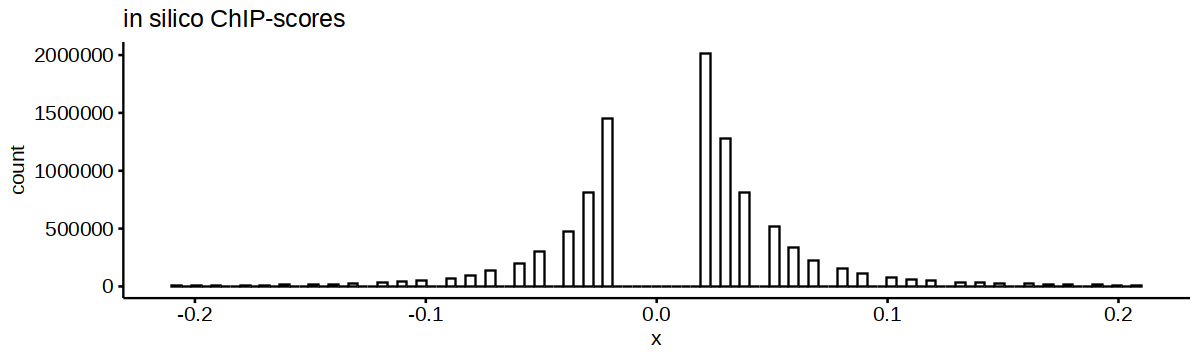

In [19]:
options(repr.plot.width=10, repr.plot.height=3)
chip_scores = as.vector(assay(motifmatcher_chip.se, 'VirtualChipScores'))
chip_scores = chip_scores[abs(chip_scores)>0.01]
gghistogram(chip_scores[abs(chip_scores)<quantile(abs(chip_scores), 0.99)], bins=100) + ggtitle('in silico ChIP-scores')

In [20]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/revision/insilico_chip"

In [21]:
######################################
## silico_chipseq_validation
######################################
library(GenomicRanges)
library(rtracklayer)

io$chip_dir.prefix <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/revisions/chip_files"
io$chip.files <- c(
  "CDX2" = file.path(io$chip_dir.prefix, "GSM2253707_Cdx2_wtEpiSCs_24h_rep1_mm10.bw"),
  "TAL1" = file.path(io$chip_dir.prefix, "GSM1692858_HP_Tal1.bw"),
  "GATA1" = file.path(io$chip_dir.prefix, "GSM1692851_HP_Gata1.bw"),
  "FOXA2" = file.path(io$chip_dir.prefix, "Foxa2.d5FS.bw"),
  "GATA4" = file.path(io$chip_dir.prefix, "GSM3223330_Gata4.d5FS.r1_m1.ucsc.bigWig"),
  "TBX5" = file.path(io$chip_dir.prefix, "Tbx5_WT_CP.bw")
)
peak_metadata.gr = makeGRangesFromDataFrame(rowData(atac.sce))
stopifnot(file.exists(io$chip.files))
TFs <- names(io$chip.files)

## calculate background ChIP signal 
chip_background.dt <- TFs %>% map(function(i) {
  data.table(
    chip_anno = i,
    median = median(import.bw(BigWigFile(io$chip.files[[i]]))$score)
  )
}) %>% rbindlist

## calculate signal 
peak_metadata_ucsc.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ucsc.gr) <- 'UCSC'
peak_metadata_ncbi.gr <- peak_metadata.gr; seqlevelsStyle(peak_metadata_ncbi.gr) <- 'NCBI'
tf2seqstyle <- rep("UCSC",length(TFs)); names(tf2seqstyle) <- TFs
tf2seqstyle["TBX5"] <- "NCBI"

to.plot <- mclapply(TFs, function(i){
  # Load virtual ChIP-seq library
    virtual_chip_tmp = copy(virtual_chip.dt)[tf==i] %>% 
        setnames('peak', 'idx') %>% 
        .[,idx:=str_replace(idx,":","-")] %>%
        .[,chr:=strsplit(idx,"-") %>% map_chr(1)] %>%
        .[,start:=as.integer(strsplit(idx,"-") %>% map_chr(2))] %>%
        .[,end:=as.integer(strsplit(idx,"-") %>% map_chr(3))] %>%
        .[,idx:=str_replace(idx,"-",":")] %>% 
        setkey(chr,start,end)

    # Load ground truth ChIP-seq data
    if (tf2seqstyle[[i]]=="UCSC") {
        tmp <- peak_metadata_ucsc.gr
    } else if (tf2seqstyle[[i]]=="NCBI") {
        tmp <- peak_metadata_ncbi.gr
    }

    chip.dt <- import.bw(BigWigFile(io$chip.files[[i]]), selection = tmp) %>% as.data.table %>%
        .[,c(1,2,3,6)] %>% setnames(c("chr", "start", "end","value")) %>%
        .[,chr:=as.character(chr)] %>%
        .[,chr:=ifelse(grepl("chr",chr),chr,paste0("chr",chr))] %>%
      setkey(chr,start,end)

      # overlap ATAC peaks with ChIP-seq signal and quantify ChIP signal
    to.plot =  virtual_chip_tmp[,c("idx","chr","start","end")] %>%
        foverlaps(chip.dt, nomatch=0) %>% 
        .[,.(value=sum(value)), b=c("idx")] %>%
        merge(virtual_chip_tmp[,c("idx","score","motif_score", "max_accessibility_score")]) %>%
        .[,chip_anno:=as.factor(i)] %>%
        return
  
}, mc.cores=10) %>% rbindlist

seq.ranges <- seq(0,1,by=0.10); names(seq.ranges) <- as.character(1:length(seq.ranges))

foo <- to.plot %>%
  .[score>=0] %>% 
  merge(chip_background.dt,by="chip_anno") %>%
  .[,log_value:=log(value+1)] %>%
  .[,c("chip_anno","idx","log_value","motif_score","score", "max_accessibility_score")] %>%
  setnames("score","score_rna_atac")

to.plot.compare_models <- foo %>%
  # Model 1: DNA
  # .[,score_dna:=minmax.normalisation(motif_score), by="chip_anno"] %>% 
  # Model 2: DNA + ATAC
  .[,score_dna_atac:=minmax.normalisation(max_accessibility_score * motif_score), by="chip_anno"] %>% .[,score_dna_atac:=score_dna_atac+0.001] %>%
  # Model 3: DNA + ATAC + RNA
  .[,score_rna_atac:=minmax.normalisation(score_rna_atac), by="chip_anno"] %>% .[,score_rna_atac:=score_rna_atac+0.001] %>%
  # Discretise values
  # .[,score_dna_group:=cut(abs(score_dna), breaks=seq.ranges)] %>% .[,score_dna_group:=seq.ranges[as.numeric(score_dna_group)]] %>%
  .[,score_dna_atac_group:=cut(abs(score_dna_atac), breaks=seq.ranges)] %>% .[,score_dna_atac_group:=seq.ranges[as.numeric(score_dna_atac_group)]] %>%
  .[,score_rna_atac_group:=cut(abs(score_rna_atac), breaks=seq.ranges)] %>% .[,score_rna_atac_group:=seq.ranges[as.numeric(score_rna_atac_group)]] %>%
  # Prepare for plotting
  melt(id.vars=c("chip_anno","idx","log_value"), measure.vars=c("score_dna_atac_group","score_rna_atac_group"), variable.name="model", value.name="predicted_value") %>%
  .[,N:=.N,by=c("model","chip_anno","predicted_value")] %>%
  .[,.(mean=mean(log_value,na.rm=T), sd=sd(log_value,na.rm=T), N=.N), by=c("model","chip_anno","predicted_value")] %>%
  # Filter settings with a small number of observations
  .[!is.na(mean) & N>=25]

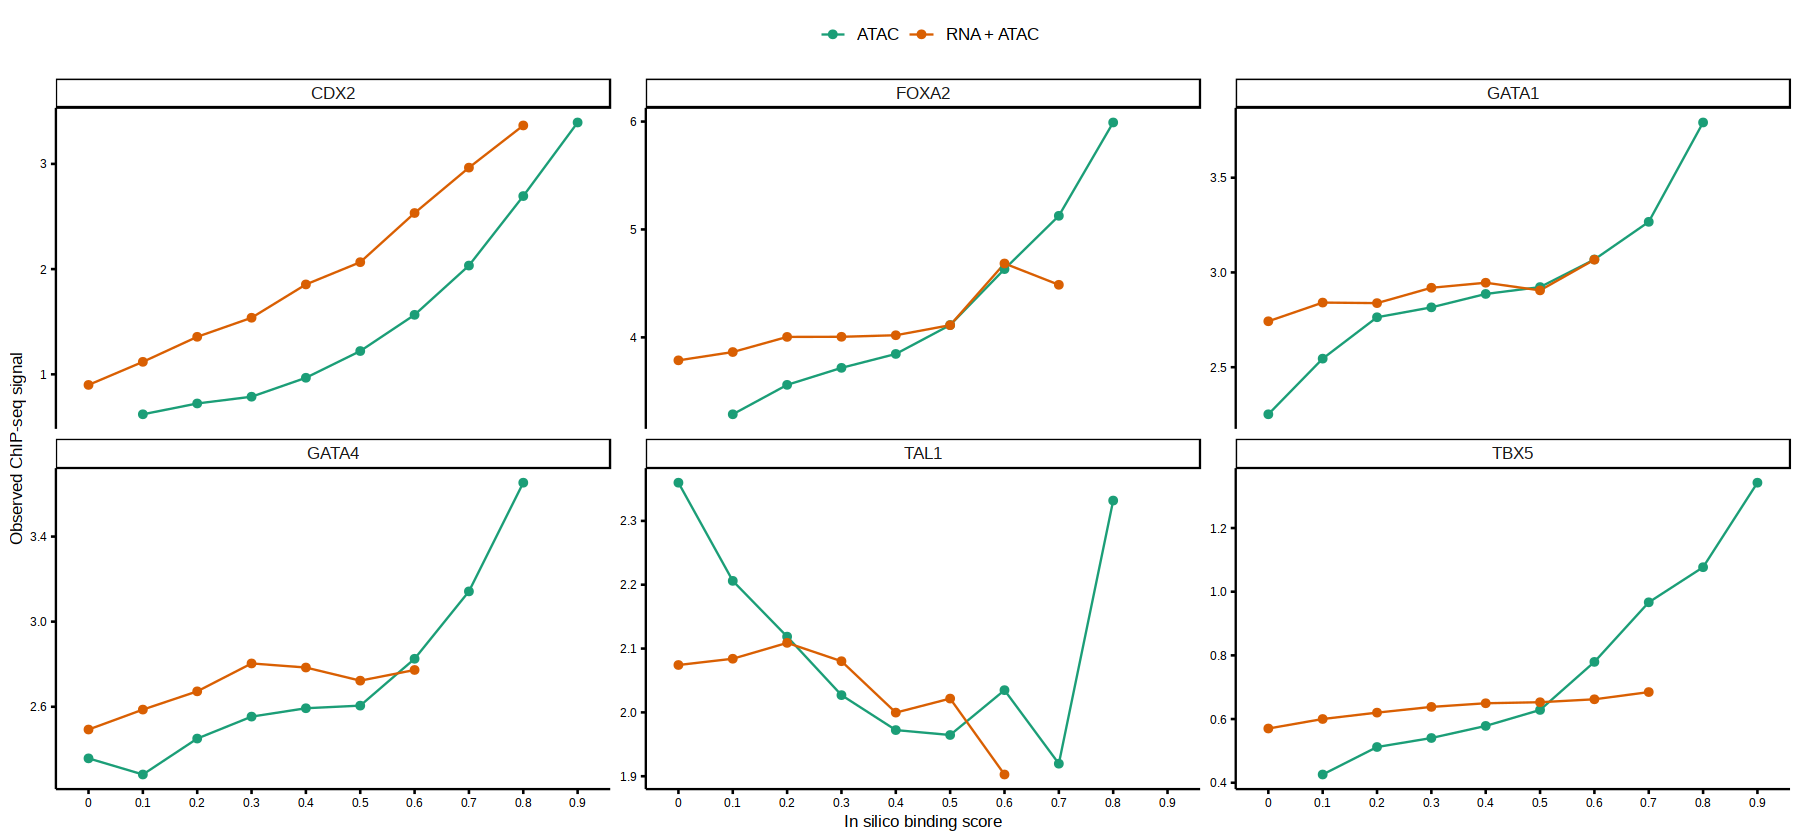

In [22]:
options(repr.plot.width=15, repr.plot.height=7)
ggline(to.plot.compare_models, x="predicted_value", y="mean", color="model", plot_type="b") +
  facet_wrap(~chip_anno, scales="free_y") +
  # geom_errorbar(aes(ymin=log_value-sd, ymax=log_value-sd), width=.2,) +
  scale_color_brewer(palette="Dark2", labels = c("ATAC", "RNA + ATAC")) +
  # scale_color_discrete(labels = c("DNA", "DNA + ATAC", "DNA + ATAC + RNA")) +
  labs(y="Observed ChIP-seq signal", x="In silico binding score") +
  theme(
    strip.background = element_rect(colour="black", fill=NA),
    axis.text = element_text(size=rel(0.55)),
    axis.title = element_text(size=rel(0.8)),
    legend.title = element_blank(),
    # legend.position = c(.26,.87)
    # legend.position = c(.06,.94)
    legend.position = "top"
  )

In [18]:
######################################
## ChromVAR - ChIP-seq
######################################
bgdPeaks.se <- readRDS(io$background_peaks)


In [19]:
# chromVAR_chip = function(atac.sce = atac.sce, 
#                            motifmatcher_chip.se = motifmatcher_chip.se,
#                            assay = 'VirtualChipScores',
#                            background = bgdPeaks.se,
#                            genome = BSgenome.Mmusculus.UCSC.mm10, # Only needed if background = NULL
#                            min_number_peaks = 50,
#                            TFs_filt = NULL,
#                            test = TRUE,
#                            method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
#                            cores = detectCores()){
    
#     if(method == 'ChromVAR'){
#         background = NULL
#         cat('Background peaks recalculated for method = ChromVAR \n')
#         if(is.null(genome)){
#             cat('Please provide genome \n')
#         }
#     }
    
#     ## Filter TFs 
#     # Filter TFs with too few peaks
#     TFs <- which(colSums(assay(motifmatcher_chip.se,"motifMatches"))>=min_number_peaks) %>% names
#     TFs.removed <- which(colSums(assay(motifmatcher_chip.se,"motifMatches"))<min_number_peaks) %>% names
#     if(!is.null(TFs_filt)){ TFs = TFs[TFs %in% TFs_filt]}

#     cat(sprintf("%s TFs removed because they don't have enough binding sites: %s \n", length(TFs.removed), paste(TFs.removed, collapse=" ")))

#     if (test) {
#       TFs <- c("FOXA2","MIXL1","GATA1","EOMES","BCL11B","DLX2","FOXC1")
#     }
#     motifmatcher_chip.se <- motifmatcher_chip.se[,TFs]    
#     stopifnot(rownames(atac.sce)==rownames(motifmatcher.se))  
    
#     if(!is.null(background)){
#         ## Load background peaks --> Ideally able to supply or newly calculated in the function
#         bgdPeaks.se = background
#         tmp <- rowRanges(bgdPeaks.se)
#         rownames(bgdPeaks.se) <- sprintf("%s:%s-%s",seqnames(tmp), start(tmp), end(tmp))
#         bgdPeaks.se <- bgdPeaks.se[rownames(atac.sce),] # subset to same peaks as in filtered atac.sce
#         bg = assay(bgdPeaks.se)
#     } else{
#         if(is.null(genome)){
#             cat('Please provide genome \n')
#             stop()
#         }
#         ## Filter non-accessible peaks
#         peaks = rowSums(assay(atac.sce, 'counts'))>0
#         atac.sce = atac.sce[peaks,]
#         motifmatcher_chip.se = motifmatcher_chip.se[peaks,]   
        
#         ## Calculate background peaks
#         cat('Calculating background peaks \n')
#         peaks = rownames(atac.sce_filt)
#         library(GenomicRanges)
#         gr <- GRanges(
#             seqnames = Rle(peaks %>% str_split(':') %>% map_chr(1)),
#             ranges = IRanges(start = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)), 
#                              end = as.numeric(peaks %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2))),
#             strand = Rle(rep('*', length(peaks))))
#         atac.rse = as(atac.sce_filt, 'RangedSummarizedExperiment')
#         atac.rse@rowRanges = gr
        
#         ## Adding background peaks
#         atac.rse <- addGCBias(atac.rse, genome = genome)
#         bg <- getBackgroundPeaks(object = atac.rse)
#     }

    
#     ## ChromVAR ChIP-seq
#     if(method == 'ArchR'){
#         cat('Running ChromVAR-ChIP-seq (ArchR implementation) \n')
        
#         featureDF <- data.frame(
#           rowSums = rowSums(assay(atac.sce)),
#           start = rowData(atac.sce)$start,
#           end = rowData(atac.sce)$end
#         )

#         # Compute deviations
#         chromvar_deviations.se <- ArchR:::.customDeviations(
#           countsMatrix = assay(atac.sce),
#           annotationsMatrix = as(assay(motifmatcher_chip.se, assay),"dgCMatrix"),
#           backgroudPeaks = bg,
#           expectation = featureDF$rowSums/sum(featureDF$rowSums),
#           prefix = "",
#           out = c("deviations", "z"),
#           threads = cores,
#           verbose = TRUE
#         )
#     } else if(method == 'ChromVAR'){
#         cat('Running ChromVAR-ChIP-seq (ChromVAR implementation) \n')
#         library(BiocParallel)
#         #stop()
#         register(MulticoreParam(cores))
#         assayNames(atac.sce) <- "counts"

#         # Compute deviations
#         chromvar_deviations_chromvar.se <- chromVAR::computeDeviations(
#           object = atac.sce,
#           annotations = assay(motifmatcher_chip.se, assay),
#           background_peaks = bg
#         )
        
#     } else{
#         print('Choose either option "ArchR" or "ChromVAR"')
#     }
        
#     return(chromvar_deviations.se)
# }

In [20]:
chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce, 
                                       motifmatcher_chip.se = motifmatcher_chip.se,
                                       assay = 'VirtualChipScores',
                                       background = bgdPeaks.se,
                                       genome = NULL, # Only needed if background = NULL
                                       min_number_peaks = 50,
                                       TFs_filt = NULL,
                                       test = FALSE,
                                       method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                       cores = detectCores())

[1] "Number of matches before filtering negative TF binding values: 18705014"
[1] "Number of matches after filtering negative TF binding values: 12393006"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 12393006"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 155425"
514 TFs removed because they don't have enough binding sites: AHR AHRR AIRE ALX1 ALX4 ARID2 ARID5A ARID5B ARNT ARNTL ARNTL2 ARX ASCL1 ASCL2 ATF1 ATF2 ATF3 ATF4 ATF5 ATF6 ATF6B ATF7 ATOH1 ATOH7 BACH1 BACH2 BARHL1 BARHL2 BARX1 BARX2 BATF BATF3 BCL11A BCL11B BCL6 BCL6B BHLHA15 BHLHE22 BHLHE23 BHLHE40 BHLHE41 BPTF BRCA1 BSX CBFB CDC5L CEBPA CEBPB CEBPD CEBPG CEBPZ CENPB CIC CLOCK CPEB1 CREB1 CREB3 CREB3L1 CREB3L3 CREB3L4 CREB5 CREM CRX CTCF CTCFL CUX1 CUX2 CXXC1 DBP DDIT3 DLX1 DLX2 DLX3 DLX4 DLX6 DMBX1 DMRT1 DMRT3 DMRTA2 DMRTC2 DNMT1 E2F1 E2F3 E2F4 E2F5 E2F6 E2F7 E2F8 E4F1 EGR1 EGR2 EGR3 EGR4 EHF ELF1 ELF3 ELF4 ELF5 ELK1 ELK4 EMX1 EMX2 EN1 EN2 EOMES EP300 EPAS1 ERF ERG ESR1 ESR

as(<lgCMatrix>, "dgCMatrix") is deprecated since Matrix 1.5-0; do as(., "dMatrix") instead



In [21]:
chromvar_deviations.se

class: SummarizedExperiment 
dim: 207 329 
metadata(0):
assays(2): deviations z
rownames(207): ALX3 AR ... ZIC5 ZSCAN10
rowData names(2): fractionMatches fractionBackgroundOverlap
colnames(329): E8.0_rep1#AAAGCGGGTGCTTTAC-1
  E8.0_rep1#AAGCGAGGTTACTAGG-1 ... E8.75_rep2#TTTAACGAGCCTGATG-1
  E8.75_rep2#TTTCCTGAGGTCTTGG-1
colData names(0):

In [22]:
# TF = 'FOXC1'

# p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
#     geom_point() +
#     viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
#     ggtitle(paste0(TF, ' - Expression')) + 
#     theme_void()

# p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(silico, 'z')[TF,]))) + 
#     geom_point() +
#     scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
#     ggtitle('ChromVAR-ChIP-seq') + 
#     theme_void()

# p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(original, 'z')[TF,]))) + 
#     geom_point() +
#     scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
#     ggtitle('ChromVAR-original') + 
#     theme_void()

# options(repr.plot.width=15, repr.plot.height=4)
# ggarrange(p1, p2, p3, nrow = 1)

ERROR: Error in ggplot(umap.dt, aes(UMAP1, UMAP2, col = as.vector(assay(rna.sce, : object 'umap.dt' not found


In [24]:
######################################
## link TF2genes virtual chip
######################################
# peak2gene (also possible to find them in the function, need to supply gene metadata with gene locations(e.g. from biomaRt))
peak2gene <- file.path(io$basedir,"results/atac/archR/peak_calling/peaks2genes/peaks2genes_all.txt.gz") 

## Load peak2gene linkages using only genomic distance
peak2gene.dt <- fread(peak2gene) %>%
  .[dist<=1e6] %>%
  .[,peak:=sprintf("chr%s:%s-%s",chr,peak.start,peak.end)]
head(peak2gene.dt)

chr,gene,ens_id,strand,gene.start,gene.end,peak.start,peak.end,peak,peak.mean,dist
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<int>,<dbl>
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3035602,3036202,chr1:3035602-3036202,3035902,37351
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3035602,3036202,chr1:3035602-3036202,3035902,66114
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3062653,3063253,chr1:3062653-3063253,3062953,10300
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3062653,3063253,chr1:3062653-3063253,3062953,39063
1,4933401J01Rik,ENSMUSG00000102693,+,3073253,3074322,3072313,3072913,chr1:3072313-3072913,3072613,640
1,Gm26206,ENSMUSG00000064842,+,3102016,3102125,3072313,3072913,chr1:3072313-3072913,3072613,29403


In [ ]:
# TF2Gene = function(rna.sce = rna.sce, 
#                    motifmatcher_chip.se = motifmatcher_chip.se,
#                    peak2gene.dt = peak2gene.dt,
#                    gene_metadata.dt = NULL, # Only needed to find peak-genes if peak2gene.dt not supplied
#                    atac.sce = NULL, # Only needed to find peak-genes if peak2gene.dt not supplied
#                    filter_genes = TRUE,
#                    min_chip_score = 0.15,
#                    distance = 5e4,
#                    assay = 'VirtualChipScores',
#                    cores = detectCores()){
    
#     if(is.null(peak2gene.dt)){
#         if(is.null(gene_metadata.dt) | is.null(atac.sce)){
#             cat('Please provide gene metadata and atac.sce \n')
#             stop()
#         }
#         cat('Annotating peaks with genes in distance window \n')
#         peak2gene.dt = annotate_peaks(gene_metadata.dt = gene_metadata.dt,
#                                   atac.sce = atac.sce,
#                                   distance = distance)
#     }
    
#     virtual_chip.mtx = assay(motifmatcher_chip.se, assay)

#     # Sanity checks
#     stopifnot(length(intersect(rownames(virtual_chip.mtx),unique(peak2gene.dt$peak)))>1e5)     

#     ## Link TFs to target genes using the virtual ChIP-seq 
#     tf2gene_chip.dt <- mclapply(colnames(virtual_chip.mtx), function(i){
#     # Select target peaks (note that we only take positive correlations into account)
#     target_peaks_i <- names(which(virtual_chip.mtx[,i]>=min_chip_score))

#     if (length(target_peaks_i)>=1) {
#         tmp <- data.table(
#           tf = i,
#           peak = target_peaks_i,
#           chip_score = virtual_chip.mtx[target_peaks_i,i]
#         ) %>% merge(peak2gene.dt[peak %in% target_peaks_i,c("peak","gene","dist")], by="peak")
#         return(tmp)
#         }
#     }, mc.cores=cores) %>% rbindlist        
                       
#     ## Filter TFs and genes 

#     TFs <- intersect(unique(tf2gene_chip.dt$tf),toupper(rownames(rna.sce)))
#     genes <- intersect(unique(tf2gene_chip.dt$gene),rownames(rna.sce))
    
#     if(filter_genes){
#         # filter out non-informative genes
#         genes <- genes[grep("*Rik|^Gm|^mt-|^Rps|^Rpl", genes, invert=T)] 
#     }

#     tf2gene_chip.dt <- tf2gene_chip.dt[tf%in%TFs & gene%in%genes,]

#     # Fetch RNA expression matrices
#     rna_tf.mtx <- logcounts(rna.sce)[str_to_title(unique(tf2gene_chip.dt$tf)),]; rownames(rna_tf.mtx) <- toupper(rownames(rna_tf.mtx))
#     rna_targets.mtx <- logcounts(rna.sce)[unique(tf2gene_chip.dt$gene),]

#     # Filter out lowly variable genes and TFs
#     rna_tf.mtx <- rna_tf.mtx[apply(rna_tf.mtx,1,var)>=1,]
#     rna_targets.mtx <- rna_targets.mtx[apply(rna_targets.mtx,1,var)>=0.1,]

#     TFs <- intersect(unique(tf2gene_chip.dt$tf),rownames(rna_tf.mtx))
#     genes <- intersect(unique(tf2gene_chip.dt$gene),rownames(rna_targets.mtx))
#     tf2gene_chip.dt <- tf2gene_chip.dt[tf%in%TFs & gene%in%genes,]

#     cat(sprintf("Number of TFs: %s \n",length(TFs)))
#     cat(sprintf("Number of genes: %s \n",length(genes)))
    
#     ## run regression 
#     GRN_coef.dt = mclapply(genes, function(i){
#         tfs <- unique(tf2gene_chip.dt[gene==i,tf])
#         tfs %>% map(function(j) {
#           x <- rna_tf.mtx[j,]
#           y <- rna_targets.mtx[i,]
#           lm.fit <- lm(y~x)
#           data.frame(tf=j, gene=i, beta=round(coef(lm.fit)[[2]],3), pvalue=format(summary(lm.fit)$coefficients[2,4], digits=3))
#         }) %>% rbindlist
#       }, mc.cores=cores) %>% rbindlist
#     # Add chip score back in so all info is 
    
#     return(GRN_coef.dt)
# }

In [25]:
a = Sys.time()
TF2Gene_links = TF2Gene(rna.sce = rna.sce, 
                   motifmatcher_chip.se = motifmatcher_chip.se,
                   peak2gene.dt = peak2gene.dt,
                   min_chip_score = 0.15,
                   distance = 5e4,
                   cores = detectCores())
b = Sys.time()
b-a
head(TF2Gene_links)

Number of TFs: 308 
Number of genes: 13112 


Time difference of 26.83716 secs

tf,gene,beta,pvalue
<chr>,<chr>,<dbl>,<chr>
AHR,Adamts6,-0.069,0.0983
HNF1B,Adamts6,-0.124,2.75e-09
MEIS1,Adamts6,-0.210,1.13e-15
NKX6-1,Adamts6,-0.170,7.26e-10
POU3F2,Adamts6,-0.181,1.31e-12
RFX4,Adamts6,-0.106,8.36e-07


Warning message in .sparse2v(x):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


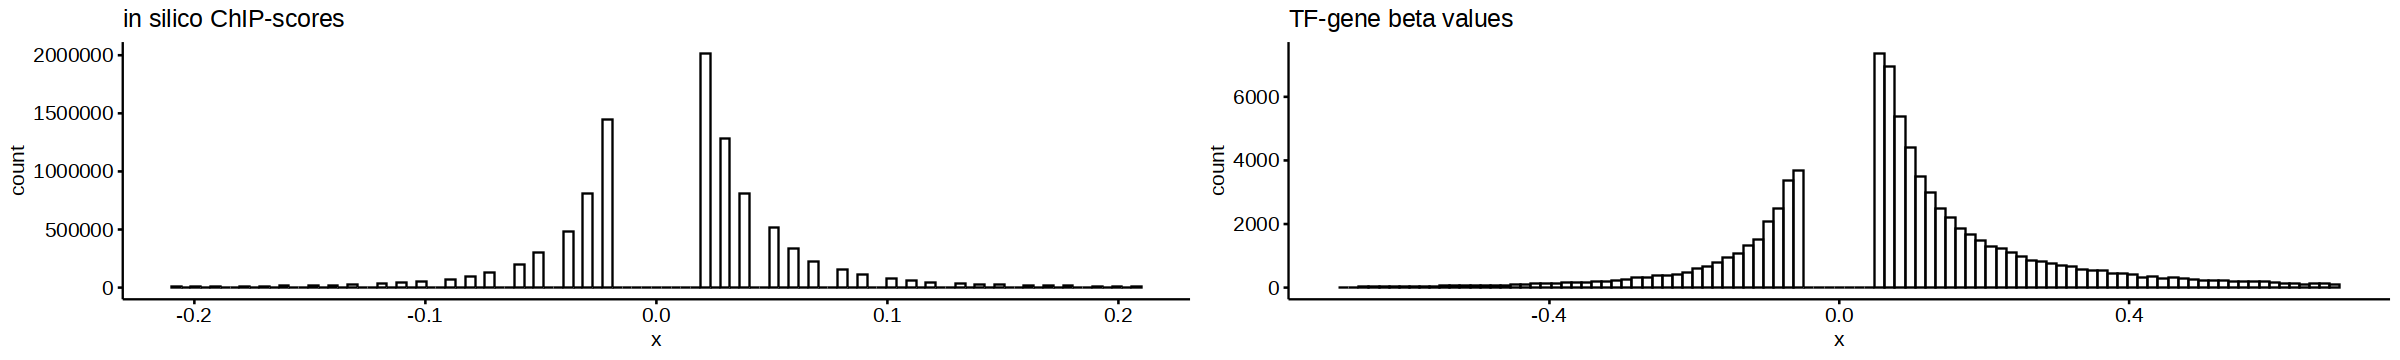

In [26]:
# Inspect silico ChIP-scores & TF-gene beta values
options(repr.plot.width=20, repr.plot.height=3)
chip_scores = as.vector(assay(motifmatcher_chip.se, 'VirtualChipScores'))
chip_scores = chip_scores[abs(chip_scores)>0.01]
p1 = gghistogram(chip_scores[abs(chip_scores)<quantile(abs(chip_scores), 0.99)], bins=100) + ggtitle('in silico ChIP-scores')
p2 = gghistogram(TF2Gene_links$beta[abs(TF2Gene_links$beta)>0.05 & abs(TF2Gene_links$beta)<quantile(abs(TF2Gene_links$beta), 0.99)], bins=100) + ggtitle('TF-gene beta values')
ggarrange(p1, p2)

In [ ]:
# annotate_peaks = function(gene_metadata.dt = gene_metadata.dt,
#                           atac.sce = atac.sce,
#                           distance = 1.5e5){
    
#     # Load gene metadata
#     gene_metadata <- copy(gene_metadata.dt) %>% 
#       .[,chr:=as.factor(sub("chr","",chr))] %>%
#       setnames("symbol","gene") %>%
#       .[, c("chr","start","end","gene","ens_id","strand")]

#     peakSet.dt <- data.table(peak = rownames(atac.sce)) %>%
#         .[,`:=`(chr = as.factor(peak %>% str_split(':') %>% map_chr(1) %>% gsub('chr', '', .)),
#                 start = as.integer(peak %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(1)),
#                 end = as.integer(peak %>% str_split(':') %>% map_chr(2) %>% str_split('-') %>% map_chr(2)))] %>%
#         .[,c('chr', 'start', 'end', 'peak')] %>% 
#       setkey(chr,start,end)

#     ## Overlap 
#     gene_metadata.ov <- copy(gene_metadata) %>%
#       .[strand=="+",c("gene.start","gene.end"):=list(start,end)] %>%
#       .[strand=="-",c("gene.start","gene.end"):=list(end,start)] %>%
#       .[strand=="+",c("start","end"):=list (gene.start-gene_window, gene.end+gene_window)] %>%
#       .[strand=="-",c("end","start"):=list (gene.start+gene_window, gene.end-gene_window)] %>% 
#       setkey(chr,start,end)

#     stopifnot((gene_metadata.ov$end-gene_metadata.ov$start)>0)

#     ov <- foverlaps(
#       peakSet.dt,
#       gene_metadata.ov,
#       nomatch = NA
#     ) %>%  .[,c("start","end"):=NULL] %>%
#       setnames(c("i.start","i.end"),c("peak.start","peak.end")) %>%
#       .[,peak.mean:=(peak.start+peak.end)/2] %>%
#       # calculate distance from the peak to the genebody
#       .[,dist:=min(abs(gene.end-peak.mean), abs(gene.start-peak.mean)), by=c("gene","ens_id","peak","strand")] %>%
#       .[strand=="+" & peak.mean>gene.start & peak.mean<gene.end,dist:=0] %>%
#       .[strand=="-" & peak.mean<gene.start & peak.mean>gene.end,dist:=0]
    
#     return(ov)   
# }

In [ ]:
### link peaks to genes based on distance
io$gene_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt"
gene_metadata.dt = fread(io$gene_metadata)
peakannotation = annotate_peaks(gene_metadata.dt = gene_metadata.dt,
                          atac.sce = atac.sce,
                          distance = 1e5)
head(peakannotation)

In [ ]:
#################
## Build GRN
#################
max_distance = 5e4
min_chip_score = 0.15
min_beta = 0.1
min_pvalue = 0.1
min_TF_expr = 7 # Min logcounts
TF_filter = NULL#c('HOXB8')
TF_TF_only = TRUE
motifmatcher_chip.se = motifmatcher_chip.se
assay = 'VirtualChipScores'
rna.sce = rna.sce
min_targets = 3

In [ ]:
tf2gene_chip.dt <- mclapply(colnames(assay(motifmatcher_chip.se, assay)), function(i){
    # Select target peaks (note that we only take positive correlations into account)
    target_peaks_i <- names(which(virtual_chip.mtx[,i]>=min_chip_score))
    if (length(target_peaks_i)>=1) {
        tmp <- data.table(
          tf = i,
          peak = target_peaks_i,
          chip_score = virtual_chip.mtx[target_peaks_i,i]
        ) %>% merge(peak2gene.dt[peak %in% target_peaks_i,c("peak","gene","dist")], by="peak")
        return(tmp)
        }
    }, mc.cores=cores) %>% rbindlist %>%
    .[,gene:=toupper(gene)] %>%
    .[chip_score >= min_chip_score & dist <= max_distance]

options(repr.plot.width=6, repr.plot.height=3)
max_expr = data.table(tf = unique(tf2gene_chip.dt$tf),
                      max_expr = rowMaxs(logcounts(rna.sce[str_to_title(unique(tf2gene_chip.dt$tf)),])))

gghistogram(max_expr$max_expr) + ggtitle('Max expression of TFs')
TF_keep = max_expr[max_expr>=min_TF_expr, toupper(tf)]

GRN_coef.dt <- TF2Gene_links %>% 
  .[pvalue<min_pvalue & abs(beta)>=min_beta] %>%
  .[,gene:=toupper(gene)] %>%
  .[tf %in% TF_keep]
if(!is.null(TF_filter)){
    GRN_coef.dt = GRN_coef.dt[tf %in% TF_filter]
}
if(TF_TF_only){
    GRN_coef.dt = GRN_coef.dt[gene %in% tf]
}

GRN.dt = merge(GRN_coef.dt, tf2gene_chip.dt, by=c('tf', 'gene')) %>% 
    .[,c('tf', 'peak', 'gene', 'dist', 'chip_score', 'beta', 'pvalue')] %>% 
    unique(by=c('tf', 'gene')) %>%
    .[,c('tf', 'gene', 'beta')] %>% 
    .[,N := .N, by='tf'] %>%
    .[N >= min_targets] 

if(TF_TF_only){
    GRN.dt = GRN.dt[gene %in% tf]
}

In [ ]:
head(TF_keep)

In [ ]:
suppressMessages(library(GGally))
suppressMessages(library(igraph))
#suppressMessages(library(network))
#suppressMessages(library(sna))
suppressMessages(library(ggraph))
suppressMessages(library(igraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))

In [ ]:
# Create node and edge data.frames
TFs <- unique(c(GRN.dt$tf,GRN.dt$gene))
node_list.dt <- data.table(node_id=1:length(TFs), node_name=TFs)
edge_list.dt <- GRN.dt[,c("tf","gene","beta")] %>% setnames(c("from","to","weight")) %>% .[!from==to]

# Create igraph object
igraph.net <- graph_from_data_frame(d = edge_list.dt)

# Create tbl_graph object for ggraph
igraph.tbl <- as_tbl_graph(igraph.net) %>%
  activate(nodes) %>%
  mutate(tf=names(V(igraph.net))) %>%
  mutate(degree=igraph::degree(igraph.net)) %>%
  mutate(eigen_centrality=eigen_centrality(igraph.net)$vector) %>%
  activate(edges) %>%
  mutate(sign=ifelse(E(igraph.net)$weight>0,"Positive","Negative")) %>%
  mutate(weight=abs(weight))

In [ ]:
gene1 = 'HOXB4'
gene2 = 'HNF1B'
options(repr.plot.width=5, repr.plot.height=5)
ggplot(as.data.table(colData(rna.sce)), aes(as.vector(logcounts(rna.sce[str_to_title(gene1),])), as.vector(logcounts(rna.sce[str_to_title(gene2),])))) + 
                    geom_point() + 
                    theme_bw()

In [ ]:
options(repr.plot.width=20, repr.plot.height=15)

ggraph(igraph.tbl, 'drl') +
  geom_edge_link(aes(edge_colour = sign, alpha=weight), edge_width=0.15, arrow=arrow(length=unit(1.5,'mm')), end_cap=circle(4,'mm')) +
  scale_edge_colour_manual(values=c("Positive"="darkgreen", "Negative"="darkred")) +  geom_node_point(size=9, alpha=0.75, col='lightblue') +
  geom_node_text(aes(label = name)) +
  theme_graph()

In [ ]:
# RNA dimreduction
library(scran)
library(scater)
decomp <- modelGeneVar(rna.sce)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=2000) %>% rownames

sce_filt <- rna.sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = 20, ntop=2000)

In [ ]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 5, min_dist = 0.3)

umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))

In [ ]:
summary(colnames(chromvar_deviations.se) == umap.dt$cell)

In [ ]:
TF = 'LEF1'

p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(rna.sce, 'logcounts')[str_to_title(TF),]))) + 
    geom_point() +
    viridis::scale_color_viridis(begin=1, end=0, name=TF) + 
    ggtitle(paste0(TF, ' - Expression')) + 
    theme_void()

p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations.se, 'z')[TF,]))) + 
    geom_point() +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-ChIP-seq') + 
    theme_void()

p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=as.vector(assay(chromvar_deviations_original.se, 'z')[TF,]))) + 
    geom_point() +
    scale_color_gradient2(low='blue', mid='lightyellow', high='red', name=TF) + 
    ggtitle('ChromVAR-original') + 
    theme_void()
options(repr.plot.width=15, repr.plot.height=4)
ggarrange(p1, p2, p3, nrow = 1)

# Silico chip wrapper

In [ ]:
# run_silico_chip_GRN = function(
#                                 rna.sce = rna.sce,
#                                 atac.sce = atac.sce,
#                                 TFs_filt = NULL,
#                                 motifmatcher.se = motifmatcher.se,
#                                 motif2gene.dt = motif2gene.dt,
#                                 TF_peak_correlation_method = 'pearson',
#                                 remove_motifs = c("T_789"),
#                                 min_number_peaks = 50,
#                                 background = bgdPeaks.se,
#                                 genome = BSgenome.Mmusculus.UCSC.mm10,
#                                 positive_only = TRUE, 
#                                 min_chip_score = 0.15,
#                                 ChromVAR_method = 'ArchR',
#                                 peak2gene.dt = peak2gene.dt,
#                                 gene_metadata.dt = NULL, # Only needed to find peak-genes if peak2gene.dt not supplied
#                                 filter_genes = TRUE,
#                                 distance = 5e4,
#                                 cores = detectCores()){

In [52]:
run_silico_chip_GRN = function(
                                rna.sce,
                                atac.sce,
                                TFs_filt,
                                motifmatcher.se,
                                motif2gene.dt,
                                TF_peak_correlation_method,
                                remove_motifs,
                                min_number_peaks,
                                background,
                                genome,
                                positive_only, 
                                min_chip_score,
                                ChromVAR_method,
                                peak2gene.dt,
                                gene_metadata.dt, # Only needed to find peak-genes if peak2gene.dt not supplied
                                filter_genes,
                                distance,
                                cores){

    tf2peak_cor.se = cor_TF_acc(
                            rna.sce = rna.sce, 
                            atac.sce = atac.sce, 
                            TFs_filt = TFs_filt,
                            motifmatcher.se = motifmatcher.se, 
                            motif2gene.dt = motif2gene.dt,
                            correlation_method = TF_peak_correlation_method, 
                            remove_motifs = remove_motifs,
                            cores = detectCores())    

    motifmatcher_chip.se = silico_chip(
                            atac.sce = atac.sce, 
                            tf2peak_cor.se = tf2peak_cor.se,
                            motifmatcher.se = motifmatcher.se,
                            motif2gene.dt = motif2gene.dt, 
                            min_number_peaks = min_number_peaks,
                            TFs_filt = TFs_filt, 
                            remove_motifs = remove_motifs,
                            cores = detectCores())

    chromvar_deviations.se = chromVAR_chip(
                            atac.sce = atac.sce, 
                            motifmatcher_chip.se = motifmatcher_chip.se,
                            assay = 'VirtualChipScores',
                            background = bgdPeaks.se,
                            genome = BSgenome.Mmusculus.UCSC.mm10, # Only needed if background = NULL
                            positive_only = positive_only, 
                            min_chip_score = min_chip_score,
                            min_number_peaks = min_number_peaks,
                            TFs_filt = TFs_filt,
                            test = FALSE,
                            method = ChromVAR_method, # Option 'ArchR' or 'ChromVAR'
                            cores = detectCores())

    GRN_coef.dt = TF2Gene(
                            rna.sce = rna.sce, 
                            motifmatcher_chip.se = motifmatcher_chip.se,
                            peak2gene.dt = peak2gene.dt,
                            gene_metadata.dt = gene_metadata.dt, # Only needed to find peak-genes if peak2gene.dt not supplied
                            atac.sce = atac.sce, # Only needed to find peak-genes if peak2gene.dt not supplied
                            filter_genes = filter_genes,
                            min_chip_score = min_chip_score,
                            distance = distance,
                            cores = detectCores())

    out = list(
        tf2peak_cor.se,
        motifmatcher_chip.se,
        chromvar_deviations.se,
        GRN_coef.dt)    
    
    names(out) = c('tf2peak_cor.se', 'motifmatcher_chip.se', 'chromvar_deviations.se', 'GRN_coef.dt')
    return(out)
}

In [53]:
test = run_silico_chip_GRN(
                            rna.sce = rna.sce,
                            atac.sce = atac.sce,
                            TFs_filt = c('GATA2', 'GATA1', 'EOMES'),
                            motifmatcher.se = motifmatcher.se,
                            motif2gene.dt = motif2gene.dt,
                            TF_peak_correlation_method = 'pearson',
                            remove_motifs = c("T_789"),
                            min_number_peaks = 50,
                            background = bgdPeaks.se,
                            genome = NULL,
                            positive_only = TRUE, 
                            min_chip_score = 0.05,
                            ChromVAR_method = 'ArchR',
                            peak2gene.dt = peak2gene.dt,
                            gene_metadata.dt = NULL, # Only needed to find peak-genes if peak2gene.dt not supplied
                            filter_genes = TRUE,
                            distance = 5e4,
                            cores = detectCores())

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 3 TFs



[1] "Number of peaks: 192251"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 3"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."
[1] "Number of matches before filtering negative TF binding values: 96877"
[1] "Number of matches after filtering negative TF binding values: 66520"
[1] "Number of matches before filtering based on minimum ChIP-seq score: 66520"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 4163"
Running ChromVAR-ChIP-seq (ArchR implementation) 
Number of TFs: 2 
Number of genes: 6687 


In [51]:
test

[1] "tf2peak_cor.se"         "motifmatcher_chip.se"   "chromvar_deviations.se"
[4] "GRN_coef.dt"

In [49]:
test[[4]][order(-beta)]

ERROR: Error in -beta: invalid argument to unary operator


In [38]:
str(test)

List of 4
 $ :Formal class 'SummarizedExperiment' [package "SummarizedExperiment"] with 5 slots
  .. ..@ colData        :Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  .. .. .. ..@ rownames       : chr [1:3] "GATA2" "EOMES" "GATA1"
  .. .. .. ..@ nrows          : int 3
  .. .. .. ..@ elementType    : chr "ANY"
  .. .. .. ..@ elementMetadata: NULL
  .. .. .. ..@ metadata       : list()
  .. .. .. ..@ listData       : Named list()
  .. ..@ assays         :Formal class 'SimpleAssays' [package "SummarizedExperiment"] with 1 slot
  .. .. .. ..@ data:Formal class 'SimpleList' [package "S4Vectors"] with 4 slots
  .. .. .. .. .. ..@ listData       :List of 2
  .. .. .. .. .. .. ..$ cor   :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. .. .. ..@ i       : int [1:96877] 2 3 24 25 30 32 35 37 47 51 ...
  .. .. .. .. .. .. .. .. ..@ p       : int [1:4] 0 36702 63573 96877
  .. .. .. .. .. .. .. .. ..@ Dim     : int [1:2] 192251 3
  .. .. .. .. .. .. .. .. 

In [ ]:
###################
## General Utils
###################    

## matrix -> sparse
dropNA <- function(x) {
  if(!is(x, "matrix")) stop("x needs to be a matrix!")
  
  zeros <- which(x==0, arr.ind=TRUE)
  ## keep zeros
  x[is.na(x)] <- 0
  x[zeros] <- NA
  x <- Matrix::drop0(x)
  x[zeros] <- 0
  x
}

# Minmax normalisation
minmax.normalisation <- function(x)
{
    return((x-min(x,na.rm=T)) /(max(x,na.rm=T)-min(x,na.rm=T)))
}

# Sort absolute
sort.abs <- function(dt, sort.field) dt[order(-abs(dt[[sort.field]]))]

# Turn data table to matrix
matrix.please<-function(x) {
  m<-as.matrix(x[,-1])
  rownames(m)<-x[[1]]
  m
}
